<a href="https://colab.research.google.com/github/ajenningsfrankston/witness2/blob/main/witness_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [105]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Running locally or in another environment")

Running in Google Colab


In [106]:
# Install the ARC-AGI SDK
!pip install -q arc-agi

# Clone the repo (skip if running locally)
import os

if IN_COLAB:
    os.chdir('/content')
    if not os.path.exists("arc-witness-envs"):
        !git clone https://github.com/Guanghan/arc-witness-envs.git

In [107]:

if os.path.basename(os.getcwd()) != "arc-witness-envs":
    os.chdir("arc-witness-envs")
print(f"Working directory: {os.getcwd()}")

Working directory: /content/arc-witness-envs


In [108]:
import sys, json, importlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from arcengine import GameAction, ActionInput, GameState

UP    = GameAction.ACTION1
DOWN  = GameAction.ACTION2
LEFT  = GameAction.ACTION3
RIGHT = GameAction.ACTION4
CONFIRM = GameAction.ACTION5
RESET = GameAction.RESET

ACTION_NAMES = {1: "UP", 2: "DOWN", 3: "LEFT", 4: "RIGHT", 5: "CONFIRM"}

# 16-color palette (index -> RGB)
PALETTE = {
    0:  [255, 255, 255],  # white
    1:  [204, 204, 204],  # light_gray
    2:  [153, 153, 153],  # gray
    3:  [102, 102, 102],  # dark_gray
    4:  [ 51,  51,  51],  # near_black
    5:  [  0,   0,   0],  # black
    6:  [229,  58, 163],  # magenta
    7:  [255, 123, 204],  # light_magenta
    8:  [249,  60,  49],  # red
    9:  [ 30, 147, 255],  # blue
    10: [136, 216, 241],  # light_blue
    11: [255, 220,   0],  # yellow
    12: [255, 133,  27],  # orange
    13: [146,  18,  49],  # maroon
    14: [ 79, 204,  48],  # green
    15: [163,  86, 214],  # purple
}

# Build matplotlib colormap from the palette
_colors_rgb = [np.array(PALETTE[i]) / 255.0 for i in range(16)]
WITNESS_CMAP = mcolors.ListedColormap(_colors_rgb)




def get_frame(game):
    """Get the current 64x64 grid from a game (as numpy array)."""
    frame_data = game.perform_action(ActionInput(id=RESET), raw=True)
    arr = frame_data.frame[0]
    return np.array(arr) if not isinstance(arr, np.ndarray) else arr


def act(game, action):
    """Perform an action and return (frame_array, frame_data)."""
    fd = game.perform_action(ActionInput(id=action), raw=True)
    arr = fd.frame[0]
    arr = np.array(arr) if not isinstance(arr, np.ndarray) else arr
    return arr, fd


def show_grid(grid, title="", ax=None):
    """Display a 64x64 color-index grid with the Witness palette."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(grid, cmap=WITNESS_CMAP, vmin=0, vmax=15,
              interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.axis('off')


# Game registry: game_id -> (module_path, class_name)
GAME_REGISTRY = {
    f"tw{i:02d}": (f"environment_files.tw{i:02d}.tw{i:02d}", f"Tw{i:02d}")
    for i in range(1, 14)
}

def load_game(game_id, seed=0):
    """Load and return a game instance by ID."""
    mod_path, cls_name = GAME_REGISTRY[game_id]
    mod = importlib.import_module(mod_path)
    return getattr(mod, cls_name)(seed=seed)

print("Setup complete.")

Setup complete.


## 2. Visualize a Puzzle Level

Each game renders to a **64×64 pixel grid** with 16 indexed colors. Let’s look at the first level of `tw01` (PathDots) — draw a path through all yellow waypoints.

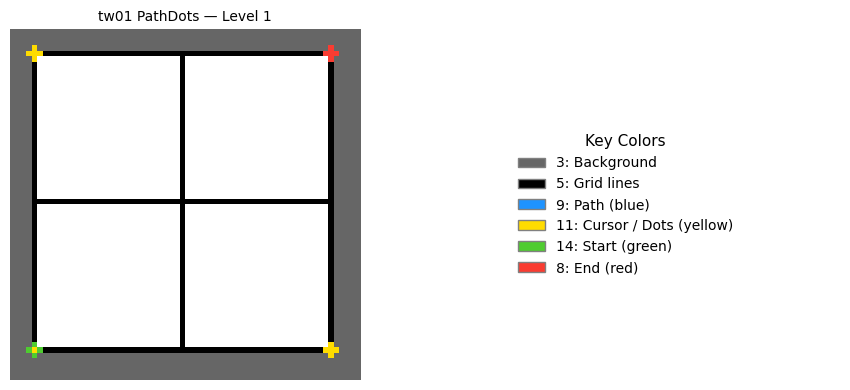

In [109]:
game = load_game("tw01")
grid = get_frame(game)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Left: the rendered grid
show_grid(grid, "tw01 PathDots — Level 1", ax=axes[0])

# Right: palette legend
semantic = {
    3: "Background", 5: "Grid lines", 9: "Path (blue)",
    11: "Cursor / Dots (yellow)", 14: "Start (green)", 8: "End (red)",
}
patches = []
labels = []
for idx, name in semantic.items():
    color = np.array(PALETTE[idx]) / 255.0
    patches.append(plt.Rectangle((0, 0), 1, 1, fc=color, ec='gray'))
    labels.append(f"{idx}: {name}")
axes[1].legend(patches, labels, loc='center', fontsize=10,
               title="Key Colors", title_fontsize=11, frameon=False)
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 3. Step-by-Step Gameplay

Solve `tw01` level 1 by executing actions one at a time. Watch the path grow on the grid.

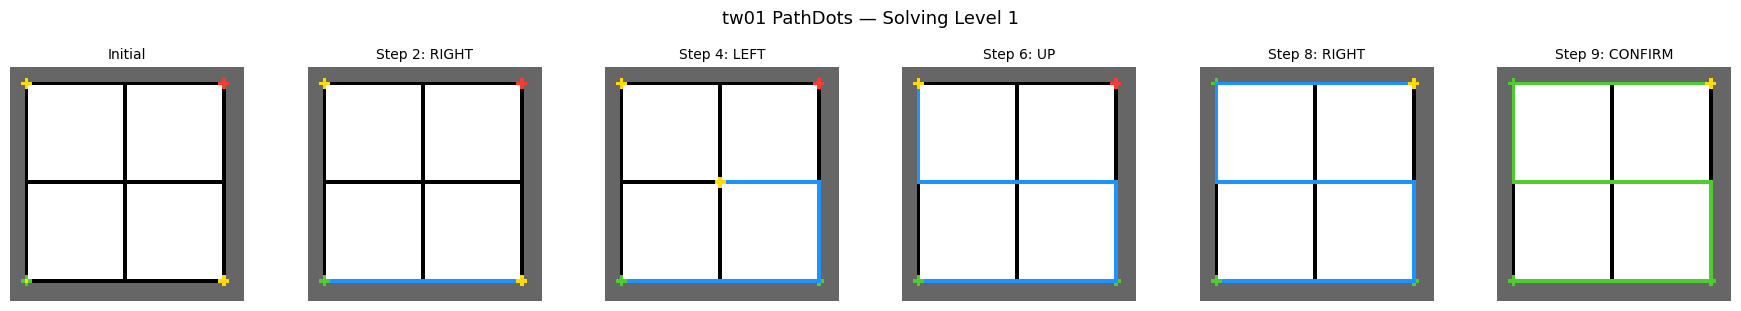

Levels completed: 1
Game state: GameState.NOT_FINISHED


In [110]:
game = load_game("tw01")

# Known solution for tw01 level 1
solution = [RIGHT, RIGHT, UP, LEFT, LEFT, UP, RIGHT, RIGHT, CONFIRM]
action_labels = ["RIGHT", "RIGHT", "UP", "LEFT", "LEFT", "UP", "RIGHT", "RIGHT", "CONFIRM"]

# Collect frames at each step
frames = []
init_grid = get_frame(game)  # reset to get initial state
frames.append(("Start", init_grid.copy()))

for action, label in zip(solution, action_labels):
    grid, fd = act(game, action)
    frames.append((label, grid.copy()))

# Show key frames (every other + last two)
indices = [0, 2, 4, 6, 8, 9]  # Start, step 2, 4, 6, 8(RIGHT), 9(CONFIRM)
fig, axes = plt.subplots(1, len(indices), figsize=(3 * len(indices), 3))
for ax, i in zip(axes, indices):
    label, grid = frames[i]
    step_label = f"Step {i}: {label}" if i > 0 else "Initial"
    show_grid(grid, step_label, ax=ax)

plt.suptitle("tw01 PathDots — Solving Level 1", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Levels completed: {fd.levels_completed}")
print(f"Game state: {fd.state}")

## 4. All 13 Games at a Glance

Each game implements a different puzzle mechanic mapping to ARC-AGI [Core Knowledge](https://arxiv.org/abs/1911.01547) priors.

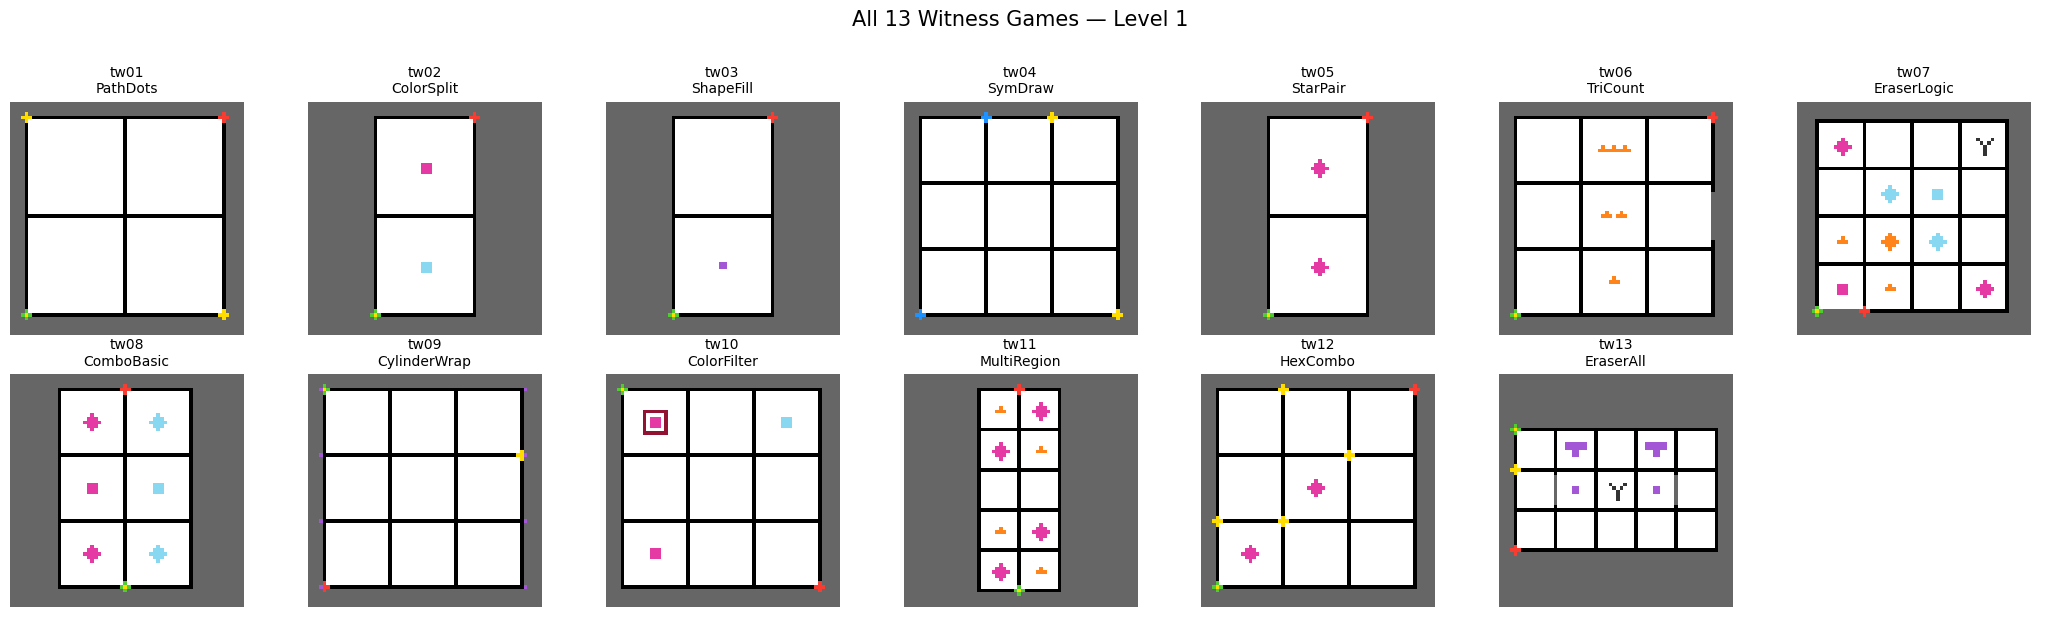

In [111]:
game_titles = {
    "tw01": "PathDots",     "tw02": "ColorSplit",   "tw03": "ShapeFill",
    "tw04": "SymDraw",      "tw05": "StarPair",     "tw06": "TriCount",
    "tw07": "EraserLogic",  "tw08": "ComboBasic",   "tw09": "CylinderWrap",
    "tw10": "ColorFilter",  "tw11": "MultiRegion",  "tw12": "HexCombo",
    "tw13": "EraserAll",
}

fig, axes = plt.subplots(2, 7, figsize=(21, 6))
axes_flat = axes.flatten()

for i, (gid, title) in enumerate(game_titles.items()):
    game = load_game(gid)
    grid = get_frame(game)
    show_grid(grid, f"{gid}\n{title}", ax=axes_flat[i])

# Hide the extra subplot (14th cell in 2x7 grid)
axes_flat[13].axis('off')

plt.suptitle("All 13 Witness Games — Level 1", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 7. Plug In Your Own Agent

Replace the `my_agent` function below with your own policy. The interface is simple:
- **Observation**: 64×64 int array (color indices 0–15)
- **Action**: one of 5 discrete actions (UP / DOWN / LEFT / RIGHT / CONFIRM)

Not solved in 50 steps. Keep improving your agent!


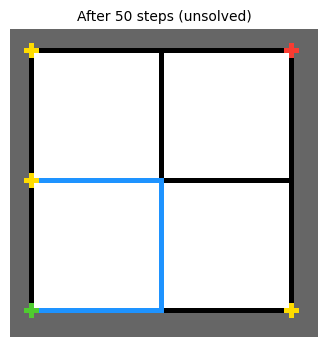

In [112]:
import random

def my_agent(observation: np.ndarray) -> GameAction:
    """
    Your agent here.

    Args:
        observation: 64x64 numpy array of color indices (0-15)

    Returns:
        GameAction: one of ACTION1 (UP), ACTION2 (DOWN),
                    ACTION3 (LEFT), ACTION4 (RIGHT), ACTION5 (CONFIRM)
    """
    ACTIONS = [GameAction.ACTION1, GameAction.ACTION2,
               GameAction.ACTION3, GameAction.ACTION4, GameAction.ACTION5]

    return random.choice(ACTIONS)


# Run your agent on tw01
game = load_game("tw01")
fd = game.perform_action(ActionInput(id=RESET), raw=True)
initial_grid = np.array(fd.frame[0])

max_steps = 50
for step in range(max_steps):
    action = my_agent(initial_grid)
    grid, fd = act(game, action)
    initial_grid = grid

    if fd.levels_completed > 0:
        print(f"Level solved in {step + 1} steps!")
        show_grid(grid, f"Solved in {step+1} steps")
        plt.show()
        break
else:
    print(f"Not solved in {max_steps} steps. Keep improving your agent!")
    show_grid(grid, f"After {max_steps} steps (unsolved)")
    plt.show()

In [113]:

"""
MAP Framework for ARC-AGI-3 Witness Games

Core principles:
1. Exploration phase: Build cognitive map of environment (no goal-seeking)
2. Knowledge extraction: Identify objects, rules, and mechanics
3. Planning phase: Use verified knowledge to generate efficient solutions
4. Verification: Check actions against learned rules before execution
"""

'\nMAP Framework for ARC-AGI-3 Witness Games\n\nCore principles:\n1. Exploration phase: Build cognitive map of environment (no goal-seeking)\n2. Knowledge extraction: Identify objects, rules, and mechanics\n3. Planning phase: Use verified knowledge to generate efficient solutions\n4. Verification: Check actions against learned rules before execution\n'

In [114]:

import numpy as np
from typing import Dict, List, Tuple, Set, Optional, Any, Callable
from dataclasses import dataclass, field
from collections import defaultdict, deque
import hashlib
from enum import Enum

# ============================================
# CORE KNOWLEDGE REPRESENTATION
# ============================================

class ObjectType(Enum):
    """Core knowledge priors for ARC-AGI-3"""
    AGENT = "agent"
    START = "start"
    GOAL = "goal"
    WAYPOINT = "waypoint"
    OBSTACLE = "obstacle"
    PATH = "path"
    SWITCH = "switch"
    COLLECTIBLE = "collectible"


@dataclass
class GameObject:
    """Represents an object in the game world"""
    obj_type: ObjectType
    position: Tuple[int, int]
    properties: Dict[str, Any] = field(default_factory=dict)
    discovered: bool = True

    def __hash__(self):
        return hash((self.obj_type, self.position))



@dataclass
class ActionAffordance:
    """What happens when an action is taken on an object"""
    action: int  # GameAction value
    precondition: Optional[Callable[..., bool]] = None  # Returns True if action allowed
    effect: Dict[str, Any] = field(default_factory=dict)
    confidence: float = 1.0


@dataclass
class Rule:
    """Discovered game rule"""
    condition: str
    effect: str
    objects_involved: Set[ObjectType]
    confidence: float = 0.0
    verified: bool = False


In [115]:

# ============================================
# COGNITIVE MAP
# ============================================

class CognitiveMap:
    """
    Stores the agent's understanding of the game world.
    Includes global knowledge (Kg) and task-specific map (Mt).
    """

    def __init__(self):
        # Global knowledge (persists across levels)
        self.global_rules: List[Rule] = []
        self.object_types: Dict[str, ObjectType] = {}
        self.action_affordances: Dict[int, List[ActionAffordance]] = defaultdict(list)

        # Task-specific map (current level)
        self.objects: Dict[Tuple[int, int], GameObject] = {}
        self.state_graph: Dict[str, Set[str]] = defaultdict(set)
        self.transition_history: List[Tuple] = []
        self.verified_facts: Set[str] = set()

    def add_object(self, obj: GameObject):
        """Add or update an object in the task map"""
        self.objects[obj.position] = obj

    def add_transition(self, pre_state: str, action: int, post_state: str, reward: float):
        """Record a state transition"""
        self.state_graph[pre_state].add(post_state)
        self.transition_history.append((pre_state, action, post_state, reward))

    def add_rule(self, rule: Rule):
        """Add a discovered rule to global knowledge"""
        # Check if rule already exists
        for existing in self.global_rules:
            if existing.condition == rule.condition and existing.effect == rule.effect:
                existing.confidence = max(existing.confidence, rule.confidence)
                if rule.verified:
                    existing.verified = True
                return
        self.global_rules.append(rule)

    def get_object_at(self, pos: Tuple[int, int]) -> Optional[GameObject]:
        """Get object at position"""
        return self.objects.get(pos)

    def get_objects_by_type(self, obj_type: ObjectType) -> List[GameObject]:
        """Get all objects of a specific type"""
        return [obj for obj in self.objects.values() if obj.obj_type == obj_type]

    def get_state_hash(self, frame: np.ndarray) -> str:
        """Generate unique hash for a game state"""
        return hashlib.md5(frame[0].tobytes()).hexdigest()


In [116]:

# ============================================
# PERCEPTION MODULE
# ============================================

class PerceptionModule:
    """
    Converts raw 64x64 pixel grids into structured objects.
    Implements the 'objectness' core prior.
    """


    def __init__(self):
        self.object_counter = 0
        # Witness 16-color palette mapping
        self.COLOR_TO_OBJECT = {
            3: None,           # Black - background
            5: 'Grid Lines',   # White - cursor/agent
            8: 'End',          # Red - goal
            9: 'Path',         # Blue - path
            11: 'Waypoint ',   # Yellow - cursor
            14: 'START',       # Green - start point
        }

    def parse_frame(self, frame: np.ndarray) -> List[GameObject]:
        """
        Parse raw frame into GameObject instances.
        Uses flood fill to identify connected components.
        """
        height, width = frame.shape
        visited = np.zeros((height, width), dtype=bool)
        objects = []

        for y in range(height):
            for x in range(width):
                if not visited[y, x]:
                    color = frame[y, x]
                    obj_type = self.COLOR_TO_OBJECT.get(color)

                    if obj_type is not None:
                        # Flood fill to get connected component
                        component = self._flood_fill(frame, x, y, color, visited)
                        if component:
                            center = self._get_centroid(component)
                            obj = GameObject(
                                obj_type=obj_type,
                                position=center,
                                properties={
                                    'color': color,
                                    'size': len(component),
                                    'pixels': component
                                }
                            )
                            objects.append(obj)
                    else:
                        # Mark as visited to skip background
                        self._mark_region(visited, frame, x, y, color)

        return objects

    def _flood_fill(self, frame: np.ndarray, x: int, y: int, target_color: int,
                    visited: np.ndarray) -> List[Tuple[int, int]]:
        """Get connected component of same color"""
        height, width = frame.shape
        stack = [(x, y)]
        component = []

        while stack:
            cx, cy = stack.pop()
            if visited[cy, cx]:
                continue
            if frame[cy, cx] != target_color:
                continue

            visited[cy, cx] = True
            component.append((cx, cy))

            # Check 4-connected neighbors
            for dx, dy in [(1,0), (-1,0), (0,1), (0,-1)]:
                nx, ny = cx + dx, cy + dy
                if 0 <= nx < width and 0 <= ny < height:
                    if not visited[ny, nx] and frame[ny, nx] == target_color:
                        stack.append((nx, ny))

        return component

    def _mark_region(self, visited: np.ndarray, frame: np.ndarray, x: int, y: int, color: int):
        """Mark entire region of given color as visited"""
        component = self._flood_fill(frame, x, y, color, visited)
        return component

    def _get_centroid(self, pixels: List[Tuple[int, int]]) -> Tuple[int, int]:
        """Calculate center of pixel group"""
        if not pixels:
            return (0, 0)
        xs = [p[0] for p in pixels]
        ys = [p[1] for p in pixels]
        return (sum(xs) // len(xs), sum(ys) // len(ys))


In [117]:

# ============================================
# HYPOTHESIS TRACKER & RULE LEARNER
# ============================================

class RuleLearner:
    """
    Discovers rules from observed transitions.
    Implements causal inference for game mechanics.
    """

    def __init__(self, cognitive_map: CognitiveMap):
        self.map = cognitive_map
        self.pending_hypotheses: List[Rule] = []

    def observe_transition(self, pre_objects: List[GameObject],
                          post_objects: List[GameObject],
                          action: int, reward: float):
        """
        Analyze a state transition to discover rules.
        """
        # Find objects that disappeared
        pre_positions = {obj.position for obj in pre_objects}
        post_positions = {obj.position for obj in post_objects}
        disappeared = pre_positions - post_positions

        # Find objects that appeared
        appeared = post_positions - pre_positions

        # Rule: If object disappears when agent interacts, it's a COLLECTIBLE
        if disappeared and self._agent_nearby(pre_objects, disappeared):
            rule = Rule(
                condition=f"agent_at_{list(disappeared)[0]}",
                effect="object_disappears",
                objects_involved={ObjectType.COLLECTIBLE},
                confidence=0.7
            )
            self.pending_hypotheses.append(rule)

        # Rule: If reward received on interaction, it's positive
        if reward > 0 and action in self._get_interaction_actions():
            rule = Rule(
                condition=f"action_{action}_on_object",
                effect="positive_reward",
                objects_involved=set(),
                confidence=0.8
            )
            self.pending_hypotheses.append(rule)

        # Rule: If level completes, this is the GOAL condition
        if reward >= 1.0:  # Win condition
            rule = Rule(
                condition="current_state",
                effect="level_complete",
                objects_involved={ObjectType.GOAL},
                confidence=1.0,
                verified=True
            )
            self.map.add_rule(rule)

    def _agent_nearby(self, objects: List[GameObject], positions: Set[Tuple[int, int]]) -> bool:
        """Check if agent is near any of the positions"""
        agent = next((obj for obj in objects if obj.obj_type == ObjectType.AGENT), None)
        if not agent:
            return False

        ax, ay = agent.position
        for px, py in positions:
            if abs(ax - px) <= 1 and abs(ay - py) <= 1:
                return True
        return False

    def _get_interaction_actions(self) -> Set[int]:
        """Actions that constitute 'interaction'"""
        return {1, 2, 3, 4, 5}  # UP, DOWN, LEFT, RIGHT, CONFIRM

    def verify_hypotheses(self, test_func) -> List[Rule]:
        """
        Test pending hypotheses against environment.
        Returns verified rules.
        """
        verified = []
        for hypothesis in self.pending_hypotheses:
            if test_func(hypothesis):
                hypothesis.verified = True
                hypothesis.confidence = 1.0
                verified.append(hypothesis)
                self.map.add_rule(hypothesis)

        self.pending_hypotheses = [h for h in self.pending_hypotheses if h not in verified]
        return verified

In [118]:


# ============================================
# EXPLORATION MODULE
# ============================================

class ExplorationModule:
    """
    Drives the initial mapping phase using information gain.
    Prioritizes actions that maximize knowledge acquisition.
    """

    def __init__(self, cognitive_map: CognitiveMap):
        self.map = cognitive_map
        self.visited_states: Set[str] = set()
        self.frontier: deque = deque()

    def get_next_action(self, current_state: str, available_actions: List) -> Optional[int]:
        """
        Choose action that maximizes information gain.
        Uses BFS-style exploration with novelty priority.
        """
        # First, try actions that lead to unvisited states
        for action in available_actions:
            # In real implementation, would simulate or check transitions
            if self._would_reveal_new_state(current_state, action):
                return action.value if hasattr(action, 'value') else action

        # If no novel actions, use systematic BFS exploration
        if self.frontier:
            return self.frontier.popleft()

        # Default: try actions in order
        return available_actions[0].value if available_actions else None

    def _would_reveal_new_state(self, state: str, action) -> bool:
        """Predict if action leads to unvisited state"""
        # Placeholder - in real implementation would use learned transition model
        return True

    def record_state(self, state_hash: str):
        """Record visited state"""
        if state_hash not in self.visited_states:
            self.visited_states.add(state_hash)
            self.frontier.append(state_hash)
            print(f"📊 Exploration: Discovered new state (total: {len(self.visited_states)})")

    def exploration_complete(self) -> bool:
        """Check if exploration phase should end"""
        # End when no new states discovered in last N steps
        # Simplified: end when frontier is empty
        return len(self.frontier) == 0 and len(self.visited_states) > 10


In [119]:

# ============================================
# PLANNER MODULE
# ============================================

class Planner:
    """
    Uses verified knowledge to generate efficient action sequences.
    Implements A* search over the cognitive map.
    """

    def __init__(self, cognitive_map: CognitiveMap):
        self.map = cognitive_map

    def plan_to_goal(self, start_state: str, goal_condition: Callable) -> List[int]:
        """
        Find shortest path to goal using verified knowledge.
        """
        # BFS over known state graph
        queue = deque([(start_state, [])])
        visited = {start_state}

        while queue:
            state, path = queue.popleft()

            # Check if goal reached
            if goal_condition(state):
                return path

            # Explore neighbors
            for next_state in self.map.state_graph.get(state, []):
                if next_state not in visited:
                    visited.add(next_state)
                    # Need to know which action leads to next_state
                    action = self._get_action_for_transition(state, next_state)
                    if action is not None:
                        queue.append((next_state, path + [action]))

        return []  # No path found

    def _get_action_for_transition(self, from_state: str, to_state: str) -> Optional[int]:
        """Find action that causes transition between states"""
        for pre, action, post, _ in self.map.transition_history:
            if pre == from_state and post == to_state:
                return action
        return None

    def plan_to_collect(self, target_positions: List[Tuple[int, int]],
                        current_pos: Tuple[int, int]) -> List[int]:
        """
        Plan shortest path to collect target objects.
        Uses Manhattan distance heuristic.
        """
        if not target_positions:
            return []

        # Find closest target
        closest = min(target_positions,
                     key=lambda p: abs(p[0]-current_pos[0]) + abs(p[1]-current_pos[1]))

        # Generate simple direction sequence (simplified)
        actions = []
        dx = closest[0] - current_pos[0]
        dy = closest[1] - current_pos[1]

        # Horizontal movement
        if dx > 0:
            actions.extend([4] * dx)  # RIGHT
        else:
            actions.extend([3] * (-dx))  # LEFT

        # Vertical movement
        if dy > 0:
            actions.extend([2] * dy)  # DOWN
        else:
            actions.extend([1] * (-dy))  # UP

        return actions


In [120]:

# ============================================
# VERIFIER MODULE
# ============================================

class Verifier:
    """
    Checks actions against learned rules before execution.
    Prevents invalid actions based on cognitive map.
    """

    def __init__(self, cognitive_map: CognitiveMap):
        self.map = cognitive_map

    def verify_action(self, action: int, current_state: str,
                     objects: List[GameObject]) -> Tuple[bool, str]:
        """
        Verify if action is valid given current knowledge.
        Returns (is_valid, reason)
        """
        # Check against known rules
        for rule in self.map.global_rules:
            if not rule.verified:
                continue

            # Check if action violates rule
            if rule.condition in current_state and rule.effect == "negative":
                return False, f"Violates rule: {rule.condition}"

        # Check if action would move agent into obstacle
        agent = next((obj for obj in objects if obj.obj_type == ObjectType.AGENT), None)
        if agent and action in [1, 2, 3, 4]:  # Movement actions
            new_pos = self._get_new_position(agent.position, action)
            if new_pos in [obj.position for obj in objects if obj.obj_type == ObjectType.OBSTACLE]:
                return False, "Would move into obstacle"

        return True, "Action verified"

    def _get_new_position(self, pos: Tuple[int, int], action: int) -> Tuple[int, int]:
        """Calculate new position after action"""
        x, y = pos
        if action == 1:  # UP
            return (x, y - 1)
        elif action == 2:  # DOWN
            return (x, y + 1)
        elif action == 3:  # LEFT
            return (x - 1, y)
        elif action == 4:  # RIGHT
            return (x + 1, y)
        return (x, y)


In [121]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
from typing import Optional, Dict, List, Tuple
import logging



class WitnessGameVisualizer:
    """
    Visualizer for Witness-style games in ARC-AGI-3 environment.
    """

    def __init__(self, figsize=(10, 10), dpi=100):
        self.figsize = figsize
        self.dpi = dpi
        self.colormap = WITNESS_CMAP

        # Witness 16-color palette mapping
        self.COLOR_TO_OBJECT = {
            3: None,           # Black - background
            5: 'Grid Lines',   # White - cursor/agent
            8: 'End',          # Red - goal
            9: 'Path',         # Blue - path
            11: 'Waypoint ',   # Yellow - cursor
            14: 'START',       # Green - start point
        }


    def plot_state(self, frame: np.ndarray,
                   title: str = "Witness Game State",
                   show_grid: bool = True,
                   show_legend: bool = True,
                   save_path: Optional[str] = None):
        """
        Plot a single game state frame.

        Args:
            frame: 64x64 numpy array of color indices (0-15)
            title: Plot title
            show_grid: Whether to show grid lines
            show_legend: Whether to show color legend
            save_path: Optional path to save the figure
        """
        fig, ax = plt.subplots(figsize=self.figsize, dpi=self.dpi)

        # Display the frame
        im = ax.imshow(frame, cmap=self.colormap, vmin=0, vmax=15, interpolation='nearest')

        # Customize appearance
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')

        # Add grid lines if requested
        if show_grid:
            self._add_grid_lines(ax, frame.shape)

        # Add legend
        if show_legend:
            self._add_legend(ax, frame)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, bbox_inches='tight', dpi=self.dpi)
            print(f"Saved plot to {save_path}")

        plt.show()
        return fig, ax

    def plot_comparison(self, frame1: np.ndarray, frame2: np.ndarray,
                        title1: str = "Before", title2: str = "After",
                        show_diff: bool = True):
        """
        Plot two game states side by side for comparison.

        Args:
            frame1: First frame (before action)
            frame2: Second frame (after action)
            title1: Title for first frame
            title2: Title for second frame
            show_diff: Whether to show difference heatmap
        """
        if show_diff:
            fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=self.dpi)
        else:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=self.dpi)

        # Plot first frame
        axes[0].imshow(frame1, cmap=self.colormap, vmin=0, vmax=15, interpolation='nearest')
        axes[0].set_title(title1, fontsize=12)
        axes[0].axis('off')

        # Plot second frame
        axes[1].imshow(frame2, cmap=self.colormap, vmin=0, vmax=15, interpolation='nearest')
        axes[1].set_title(title2, fontsize=12)
        axes[1].axis('off')

        # Plot difference if requested
        if show_diff:
            diff = (frame1 != frame2).astype(int)
            axes[2].imshow(diff, cmap='Reds', interpolation='nearest')
            axes[2].set_title("Difference (changed pixels)", fontsize=12)
            axes[2].axis('off')

            changed_count = np.sum(diff)
            axes[2].text(0.5, -0.05, f"Changed pixels: {changed_count}",
                        transform=axes[2].transAxes, ha='center', fontsize=10)

        plt.tight_layout()
        plt.show()

    def plot_with_annotations(self, frame: np.ndarray,
                              objects: List[Dict],
                              title: str = "Annotated Game State"):
        """
        Plot game state with detected object annotations.

        Args:
            frame: 64x64 numpy array
            objects: List of detected objects with 'position' and 'type'
            title: Plot title
        """
        fig, ax = plt.subplots(figsize=self.figsize, dpi=self.dpi)

        # Display frame
        ax.imshow(frame, cmap=self.colormap, vmin=0, vmax=15, interpolation='nearest')

        # Add annotations
        for obj in objects:
            x, y = obj['position']
            obj_type = obj.get('type', 'Unknown')

            # Draw circle around object
            circle = patches.Circle((x, y), radius=2, linewidth=2,
                                    edgecolor='red', facecolor='none')
            ax.add_patch(circle)

            # Add label
            ax.text(x + 3, y - 3, obj_type, fontsize=8, color='white',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')
        plt.tight_layout()
        plt.show()

    def animate_sequence(self, frames: List[np.ndarray],
                         interval: int = 200,
                         save_path: Optional[str] = None):
        """
        Animate a sequence of game states.

        Args:
            frames: List of frames to animate
            interval: Delay between frames in milliseconds
            save_path: Optional path to save animation
        """
        from matplotlib.animation import FuncAnimation

        fig, ax = plt.subplots(figsize=self.figsize, dpi=self.dpi)
        im = ax.imshow(frames[0], cmap=self.colormap, vmin=0, vmax=15, interpolation='nearest')
        ax.set_title("Game State Sequence", fontsize=14)
        ax.axis('off')

        def update(frame_idx):
            im.set_array(frames[frame_idx])
            ax.set_title(f"Frame {frame_idx + 1}/{len(frames)}", fontsize=12)
            return [im]

        anim = FuncAnimation(fig, update, frames=len(frames), interval=interval, blit=True)

        if save_path:
            anim.save(save_path, writer='pillow', fps=1000//interval)
            print(f"Saved animation to {save_path}")

        plt.show()
        return anim

    def _add_grid_lines(self, ax, shape):
        """Add grid lines to the plot"""
        height, width = shape

        # Major grid every 8 cells (typical Witness grid size)
        major_step = 8
        for i in range(0, width, major_step):
            ax.axvline(x=i - 0.5, color='gray', linewidth=0.5, alpha=0.5)
        for i in range(0, height, major_step):
            ax.axhline(y=i - 0.5, color='gray', linewidth=0.5, alpha=0.5)

    def _add_legend(self, ax, frame):
        """Add color legend for unique colors present in frame"""
        unique_colors = np.unique(frame)

        # Create legend elements
        legend_elements = []
        for color_idx in unique_colors:
            if color_idx in self.COLOR_TO_OBJECT:
                color_name = self.COLOR_TO_OBJECT[color_idx]
                color_patch = patches.Patch(color=np.array(PALETTE[color_idx]) / 255.0,
                                           label=f"{color_idx}: {color_name}")
                legend_elements.append(color_patch)

        if legend_elements:
            ax.legend(handles=legend_elements, loc='upper left',
                     bbox_to_anchor=(1.02, 1), fontsize=8)


# ============================================
# PARSING FUNCTIONS
# ============================================

def parse_witness_state(frame: np.ndarray) -> Dict:
    """
    Parse a Witness game frame into structured information.

    Args:
        frame: 64x64 numpy array of color indices

    Returns:
        Dictionary with parsed state information
    """
    state = {
        'start_points': [],
        'goal_points': [],
        'waypoints': [],
        'agent_positions': [],
        'path_pixels': [],
        'obstacles': []
    }



    for y in range(frame.shape[0]):
        for x in range(frame.shape[1]):
            color = frame[y, x]

            if color == 14:  # Start point (green)
                state['start_points'].append((x, y))
            elif color == 8:  # Goal (red)
                state['goal_points'].append((x, y))
            elif color == 11:  # Waypoint (yellow)
                state['waypoints'].append((x, y))
            elif color == 5:  # Agent (white)
                state['agent_positions'].append((x, y))
            elif color == 9:  # Path (light blue)
                state['path_pixels'].append((x, y))

    return state

def print_state_summary(state: Dict):
    """Print human-readable summary of parsed state"""
    print("\n" + "="*50)
    print("GAME STATE SUMMARY")
    print("="*50)

    print(f"🎯 Start Points: {len(state['start_points'])}")
    for pos in state['start_points']:
        print(f"   {pos}")

    print(f"\n🏁 Goal Points: {len(state['goal_points'])}")
    for pos in state['goal_points']:
        print(f"   {pos}")

    print(f"\n📍 Waypoints: {len(state['waypoints'])}")
    for pos in state['waypoints'][:10]:  # Limit display
        print(f"   {pos}")
    if len(state['waypoints']) > 10:
        print(f"   ... and {len(state['waypoints']) - 10} more")

    print(f"\n👤 Agent Positions: {len(state['agent_positions'])}")
    for pos in state['agent_positions']:
        print(f"   {pos}")

    print(f"\n🛤️ Path Length: {len(state['path_pixels'])} pixels")
    print(f"🧱 Obstacles: {len(state['obstacles'])}")


# ============================================
# USAGE EXAMPLES
# ============================================

def demo_from_environment():
    """
    Example of plotting from actual ARC-AGI-3 environment.
    """
    try:
        from arc_agi import Arcade, OperationMode
        from arcengine import GameAction, GameState

        # Initialize environment
        arcade = Arcade(
            operation_mode=OperationMode.OFFLINE,
            # Update this path to your arc-witness-envs location
            environments_dir="/content/arc-witness-envs/environment_files",
        )
        env = arcade.make("tw01")  # PathDots game

        # Get initial state
        obs = env.reset()
        frame = obs.frame[0] if hasattr(obs, 'frame') else obs.grid

        # Create visualizer
        viz = WitnessGameVisualizer(figsize=(8, 8))

        # Plot initial state
        viz.plot_state(frame, title="tw01 PathDots - Initial State")

        # Parse and print state summary
        state = parse_witness_state(frame)
        print_state_summary(state)

        # Take a move and compare
        obs = env.step(GameAction.ACTION4)  # Move right
        new_frame = obs.frame[0] if hasattr(obs, 'frame') else obs.grid

        # Show before/after comparison
        viz.plot_comparison(frame, new_frame,
                           title1="Before Move",
                           title2="After Move Right")

    except ImportError:
        print("arc-agi not installed. Run: pip install arc-agi")



#demo_from_environment()
#demo_synthetic


In [132]:

# ============================================
# MAP FRAMEWORK CONTROLLER
# ============================================

class MAPFramework:
    """
    Main controller implementing the Map-then-Act framework.
    Orchestrates perception, exploration, learning, and planning phases.
    """

    def __init__(self, env, max_exploration_steps: int = 500):
        self.env = env
        self.max_exploration_steps = max_exploration_steps

        # Core components
        self.cognitive_map = CognitiveMap()
        self.perception = PerceptionModule()
        self.rule_learner = RuleLearner(self.cognitive_map)
        self.explorer = ExplorationModule(self.cognitive_map)
        self.planner = Planner(self.cognitive_map)
        self.verifier = Verifier(self.cognitive_map)

        # State tracking
        self.current_obs = None
        self.current_objects = []
        self.phase = "exploration"  # exploration, planning, execution
        self.action_plan = []

    def run(self) -> float:
        """
        Main loop: Explore -> Learn -> Plan -> Execute
        Returns final score
        """
        self.current_obs = self.env.reset()

        print("=" * 60)
        print("MAP Framework Starting")
        print("=" * 60)

        # PHASE 1: EXPLORATION
        print("\n🔍 PHASE 1: EXPLORATION - Building cognitive map...")
        self._exploration_phase()
        self.display_map_state()

        # PHASE 2: PLAN
        print("\n📋 PHASE 2: PLANNING - Generating solution...")
        self._planning_phase()
        self.display_map_state()

        # PHASE 3: EXECUTION WITH VERIFICATION
        print("\n⚡ PHASE 3: EXECUTION - Acting on plan...")
        score = self._execution_phase()

        print(f"\n✅ Complete! Final Score: {score}")
        return score

    def display_map_state(self):
        """Display current cognitive map state"""
        print(f"\n{'='*50}")
        print(f"MAP STATE - Phase: {self.phase}")
        print(f"{'='*50}")
        print(f"Objects: {len(self.cognitive_map.objects)}")
        print(f"States: {len(self.cognitive_map.state_graph)}")
        print(f"Rules: {len(self.cognitive_map.global_rules)}")

        if self.cognitive_map.objects:
            print("\nObjects:")
            print(self.cognitive_map.objects)
            for obj in list(self.cognitive_map.objects.values()):
                print(f"Type  - {obj.obj_type} at {obj.position}  size {obj.properties['size']}")


    def _exploration_phase(self):
        """Systematically explore to discover game mechanics"""
        steps = 0

        while steps < self.max_exploration_steps:
            # Parse current frame
            objects = self.perception.parse_frame(self.current_obs.frame[0])
            state_hash = self.cognitive_map.get_state_hash(self.current_obs.frame)

            # Record objects
            for obj in objects:
                self.cognitive_map.add_object(obj)

            # Record state
            self.explorer.record_state(state_hash)

            # Get next action from exploration module
            actions = self.env.action_space
            action = self.explorer.get_next_action(state_hash, actions)


            if action is None:
                break

            # Take action
            pre_objects = objects.copy()
            self.current_obs = self.env.step(action)
            steps += 1

            # Parse post-action state
            post_objects = self.perception.parse_frame(self.current_obs.frame[0])
            post_hash = self.cognitive_map.get_state_hash(self.current_obs.frame)

            # Record transition
            reward = 1.0 if self.current_obs.state == "WIN" else 0.0
            self.cognitive_map.add_transition(state_hash, action, post_hash, reward)

            # Learn rules from transition
            self.rule_learner.observe_transition(pre_objects, post_objects, action, reward)

            # Progress indicator
            if steps % 50 == 0:
                print(f"   Exploration step {steps}: discovered {len(self.cognitive_map.objects)} objects, "
                      f"{len(self.cognitive_map.state_graph)} states")

            # Check if level solved during exploration
            if self.current_obs.state == "WIN":
                print(f"   🎉 Level solved during exploration at step {steps}!")
                return

        print(f"   Exploration complete: {len(self.cognitive_map.objects)} objects, "
              f"{len(self.cognitive_map.state_graph)} states, "
              f"{len(self.cognitive_map.global_rules)} rules")

    def _planning_phase(self):
        """Generate action plan using learned knowledge"""

        # Identify goal objects
        goals = self.cognitive_map.get_objects_by_type(ObjectType.GOAL)
        waypoints = self.cognitive_map.get_objects_by_type(ObjectType.WAYPOINT)
        agent = self.cognitive_map.get_objects_by_type(ObjectType.AGENT)

        current_pos = agent[0].position if agent else (0, 0)

        # Plan to collect waypoints first
        if waypoints:
            waypoint_positions = [w.position for w in waypoints]
            self.action_plan = self.planner.plan_to_collect(waypoint_positions, current_pos)
            print(f"   Planned path to {len(waypoints)} waypoints: {len(self.action_plan)} actions")

        # Add final confirmation if needed
        if goals:
            # Plan to reach goal
            goal_pos = goals[0].position
            goal_actions = self.planner.plan_to_collect([goal_pos], current_pos)
            self.action_plan.extend(goal_actions)
            # Add CONFIRM action (ACTION5)
            self.action_plan.append(5)
            print(f"   Added goal approach and confirmation")

    def _execution_phase(self) -> float:
        """Execute plan with verification at each step"""
        steps_taken = 0

        for action in self.action_plan:
            # Verify action before execution
            objects = self.perception.parse_frame(self.current_obs.frame[0])
            is_valid, reason = self.verifier.verify_action(action,
                self.cognitive_map.get_state_hash(self.current_obs.frame), objects)

            if not is_valid:
                print(f"   ⚠️ Action {action} invalid: {reason}")
                # Fall back to exploration
                continue

            # Execute verified action
            self.current_obs = self.env.step(action)
            steps_taken += 1

            # Check if solved
            if self.current_obs.state == "WIN":
                print(f"   🎉 Level solved in {steps_taken} execution steps!")
                break

        # Return score (simplified)
        return 1.0 if self.current_obs.state == "WIN" else 0.0


In [131]:
def run_witness_game(game_id: str = "tw01"):
    """
    Run MAP framework on a Witness game.

    Args:
        game_id: Witness game ID (tw01, tw02, ..., tw13)
    """
    try:
        from arc_agi import Arcade, OperationMode
        from arcengine import GameAction, GameState

        # Initialize environment
        arcade = Arcade(
            operation_mode=OperationMode.OFFLINE,
            # Update this path to your arc-witness-envs location
            environments_dir="/content/arc-witness-envs/environment_files",
        )

        env = arcade.make(game_id=game_id)
        # Fix: Use the global game_titles dictionary for accurate title display.
        # Original: print(f"🎮 Playing {game_id}: {arcade.get_environments()[0].title}")
        print(f"🎮 Playing {game_id}: {game_titles[game_id]}") # Fixed line

        # Run MAP framework
        agent = MAPFramework(env, max_exploration_steps=300)
        score = agent.run()

        return score

    except ImportError:
        print("Please install arc-agi and arc-witness-envs first")
        print("pip install arc-agi")
        print("git clone https://github.com/Guanghan/arc-witness-envs.git")
        return 0.0

# Example: Run on PathDots game
run_witness_game("tw01")

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-05-22 01:19:38 | INFO | Created new scorecard: 55c302f6-249b-4936-8975-c27777893306


INFO:arc_agi.base:Created new scorecard: 55c302f6-249b-4936-8975-c27777893306


2026-05-22 01:19:38 | INFO | Found latest version of tw01: tw01 (downloaded: 2026-03-05 00:00:00+00:00)


INFO:arc_agi.base:Found latest version of tw01: tw01 (downloaded: 2026-03-05 00:00:00+00:00)


🎮 Playing tw01: PathDots
MAP Framework Starting

🔍 PHASE 1: EXPLORATION - Building cognitive map...
📊 Exploration: Discovered new state (total: 1)
📊 Exploration: Discovered new state (total: 2)
📊 Exploration: Discovered new state (total: 3)
   Exploration step 50: discovered 13 objects, 3 states
   Exploration step 100: discovered 13 objects, 3 states
   Exploration step 150: discovered 13 objects, 3 states
   Exploration step 200: discovered 13 objects, 3 states
   Exploration step 250: discovered 13 objects, 3 states
   Exploration step 300: discovered 13 objects, 3 states
   Exploration complete: 13 objects, 3 states, 0 rules

MAP STATE - Phase: exploration
Objects: 13
States: 3
Rules: 0

Objects:
{(4, 4): GameObject(obj_type='Waypoint ', position=(4, 4), properties={'color': np.int8(11), 'size': 5, 'pixels': [(4, 3), (4, 4), (4, 5), (3, 4), (5, 4)]}, discovered=True), (58, 4): GameObject(obj_type='End', position=(58, 4), properties={'color': np.int8(8), 'size': 5, 'pixels': [(58, 3

AttributeError: 'dict' object has no attribute 'size'

In [133]:
def run_witness_game(game_id: str = "tw01"):
    """
    Run MAP framework on a Witness game.

    Args:
        game_id: Witness game ID (tw01, tw02, ..., tw13)
    """
    try:
        from arc_agi import Arcade, OperationMode
        from arcengine import GameAction, GameState

        # Initialize environment
        arcade = Arcade(
            operation_mode=OperationMode.OFFLINE,
            # Update this path to your arc-witness-envs location
            environments_dir="/content/arc-witness-envs/environment_files",
        )

        env = arcade.make(game_id=game_id)
        # Fix: Use the global game_titles dictionary for accurate title display.
        # Original: print(f"🎮 Playing {game_id}: {arcade.get_environments()[0].title}")
        print(f"🎮 Playing {game_id}: {game_titles[game_id]}") # Fixed line

        # Run MAP framework
        agent = MAPFramework(env, max_exploration_steps=300)
        score = agent.run()

        return score

    except ImportError:
        print("Please install arc-agi and arc-witness-envs first")
        print("pip install arc-agi")
        print("git clone https://github.com/Guanghan/arc-witness-envs.git")
        return 0.0

# Example: Run on PathDots game
run_witness_game("tw01")

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-05-22 01:22:17 | INFO | Created new scorecard: 5e72e0a3-19c9-46f1-aacb-ae5e01cbf7c7


INFO:arc_agi.base:Created new scorecard: 5e72e0a3-19c9-46f1-aacb-ae5e01cbf7c7


2026-05-22 01:22:17 | INFO | Found latest version of tw01: tw01 (downloaded: 2026-03-05 00:00:00+00:00)


INFO:arc_agi.base:Found latest version of tw01: tw01 (downloaded: 2026-03-05 00:00:00+00:00)


🎮 Playing tw01: PathDots
MAP Framework Starting

🔍 PHASE 1: EXPLORATION - Building cognitive map...
📊 Exploration: Discovered new state (total: 1)
📊 Exploration: Discovered new state (total: 2)
📊 Exploration: Discovered new state (total: 3)
   Exploration step 50: discovered 13 objects, 3 states
   Exploration step 100: discovered 13 objects, 3 states
   Exploration step 150: discovered 13 objects, 3 states
   Exploration step 200: discovered 13 objects, 3 states
   Exploration step 250: discovered 13 objects, 3 states
   Exploration step 300: discovered 13 objects, 3 states
   Exploration complete: 13 objects, 3 states, 0 rules

MAP STATE - Phase: exploration
Objects: 13
States: 3
Rules: 0

Objects:
{(4, 4): GameObject(obj_type='Waypoint ', position=(4, 4), properties={'color': np.int8(11), 'size': 5, 'pixels': [(4, 3), (4, 4), (4, 5), (3, 4), (5, 4)]}, discovered=True), (58, 4): GameObject(obj_type='End', position=(58, 4), properties={'color': np.int8(8), 'size': 5, 'pixels': [(58, 3

0.0